## Summarize the results

### ELBO

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import torch
import re
import pandas as pd
import seaborn as sns
from data_simulation import simulate_data
from model_holdout import AEVB

In [6]:
# The updated file pattern
file_pattern = 'results/simulation_1/output_*.pth'
T_train = 1000
elbo_data = []
last_elbo_data = []

# New regex includes lam
pattern = r'_K(\d+)_seed(\d+)_lambda([\d.]+)\.pth$'

file_paths = glob.glob(file_pattern)
for file_path in file_paths:
    file_name = file_path.split('/')[-1]
    match = re.search(pattern, file_name)
    if match:
        K_num = int(match.group(1))
        seed = int(match.group(2))
        
        lam_str = match.group(3)  # e.g. '1.23'
        lam_val = float(lam_str)  # convert to float

        # Load the data
        # data = torch.load(file_path, weights_only=False)
        data = torch.load(
            file_path,
            map_location="cpu",
            weights_only=False
        )
        data_tmp = simulate_data()[0]
        # recon_erorr = np.sqrt(np.mean((data_tmp[T_train:]-data["predictions"]["y_pred"].cpu().numpy())**2))
        if "ELBO" in data:
            elbo_list = data['ELBO']
            elbo_data.append({
                'seed': seed, 
                'K': K_num, 
                'lambda': lam_val,  # store lambda here
                'ELBO': elbo_list,
                # "rmse": data["predictions"]["rmse"].cpu().numpy(),
            })
            last_elbo_data.append({
                'seed': seed, 
                'K': K_num, 
                'lambda': lam_val, 
                'ELBO': elbo_list[-1],
                # "rmse": data["predictions"]["rmse"].cpu().numpy(),
            })

# Convert to dataframes
df_last_elbo = pd.DataFrame(last_elbo_data)
df_elbo = pd.DataFrame(elbo_data)


In [8]:
best_configs = []
# mean_recon_error_per_lambda = df_last_elbo.groupby("lambda")["rmse"].mean().astype(float)
best_lambda = 1.0 #mean_recon_error_per_lambda.idxmin()
df_best_lambda = df_last_elbo[(df_last_elbo["lambda"] == best_lambda) ]
idx_min_ELBO = df_best_lambda["ELBO"].idxmin()
best_seed = df_best_lambda.loc[idx_min_ELBO, "seed"]
best_config = df_best_lambda.loc[idx_min_ELBO]
best_configs.append(best_config)
    
df_best_configs = pd.DataFrame(best_configs)
print(df_best_configs)

    seed    K  lambda          ELBO
21  15.0  6.0     1.0 -15221.782227


In [9]:
df_min_elbo = df_best_configs

In [44]:
# df_last_elbo.sort_values(by="ELBO", ascending=False, inplace=True)

In [45]:
# palette = sns.color_palette("husl", df_last_elbo['seed'].nunique())

# # Number of sets and columns
# num_sets = df_last_elbo['K'].nunique()
# cols = 2
# rows = (num_sets + cols - 1) // cols  # Calculate the number of rows needed

# # Create subplots
# fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# # Flatten the axes array for easy indexing
# axes = axes.flatten()

# # Group by 'set' and plot histograms for 'last_elbo'
# for i, (set_num, group) in enumerate(df_last_elbo.groupby('K')):
#     ax = axes[i]
    
#     # Plot each seed with a different color
#     for seed, seed_group in group.groupby('seed'):
#         ax.hist(seed_group['ELBO'], bins=10, alpha=0.75, label=f'Seed {seed}', color=palette[seed_group['seed'].iloc[0] % len(palette)])
    
#     ax.set_title(f'Histogram of Last ELBOs for K {set_num}')
#     ax.set_xlabel('Last ELBO')
#     ax.set_ylabel('Frequency')
#     # ax.legend()
#     ax.grid(True)

# # Remove any unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()


In [46]:
# palette = sns.color_palette("husl", df_elbo['seed'].nunique())

# # Number of sets and columns
# num_sets = df_elbo['set'].nunique()
# cols = 2
# rows = (num_sets + cols - 1) // cols  # Calculate the number of rows needed

# # Create subplots
# fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# # Flatten the axes array for easy indexing
# axes = axes.flatten()

# # Group by 'set' and plot line plots for 'ELBO'
# for i, (set_num, group) in enumerate(df_elbo.groupby('set')):
#     ax = axes[i]
    
#     # Plot each seed with a different color
#     for seed, seed_group in group.groupby('seed'):
#         elbo_values = seed_group['ELBO'].values[0]  # Get the ELBO list for this seed
#         ax.plot(elbo_values, label=f'Seed {seed}', color=palette[seed_group['seed'].iloc[0] % len(palette)], alpha=0.5)
    
#     ax.set_title(f'ELBO Progression for Set {set_num}')
#     ax.set_xlabel('Iteration')
#     ax.set_ylabel('ELBO')
#     ax.legend()
#     ax.grid(True)

# # Remove any unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()


In [10]:
T = 1000; K = 6; D = 16

#### Set 1

In [11]:
from model_holdout import AEVB

In [12]:
# output_path = "results/simulation005/output_K6_seed11_lambda0.05.pth" #output_path_prefix+str("5")+ "_seed"+str("228")+".pth" 630
i = 0
output_path_prefix = "results/simulation_1/output_"
output_path = output_path_prefix + "K" + str(int(df_min_elbo["K"].iloc[i])) + "_seed" + str(int(df_min_elbo["seed"].iloc[i])) + "_lambda" + str(df_min_elbo["lambda"].iloc[i]) + ".pth"

model_path = output_path.replace("output", "model")

In [13]:
data = simulate_data()[0]

In [14]:
output = torch.load(output_path, weights_only=False)
model = AEVB(T=T, D=D, K=K, lambda_h=0.02)
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [15]:
h_true = output['true_h']
h_learned = torch.sigmoid(output['h_logit']).detach().cpu().numpy()
z_true = output['Z']
z_learned = output['z'].detach().cpu().numpy()
theta_true = output['true_theta_a']
theta_learned = torch.abs(model.theta).detach().cpu().numpy()
mu_true = output['rate']
mu_approx = output['mu_approx'].detach().cpu().numpy()
z0_learned = output['z0'].detach().cpu().numpy()
mu0_approx = output['mu0_approx'].detach().cpu().numpy()

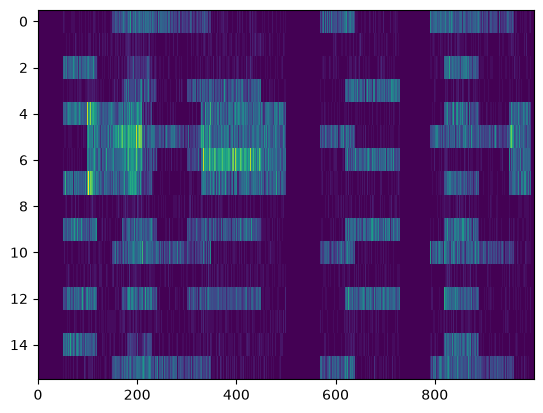

In [16]:
plt.imshow(data.T, aspect="auto", interpolation="none")
plt.show()

In [17]:
h_hard = (h_learned>0.5)
count_ones = np.sum(h_hard, axis=0)

# Step 3: Sort the indices based on the count of ones in descending order
sorted_indices = np.argsort(-count_ones)

# Step 4: Reorder the arrays using the sorted indices
h_hard_sorted = h_hard[:, sorted_indices]
h_est_sorted = h_learned[:, sorted_indices]

In [18]:
count_ones_true = np.sum(h_true, axis=0)

# Step 3: Sort the indices based on the count of ones in descending order
sorted_indices_true = np.argsort(-count_ones_true)

# Step 4: Reorder the arrays using the sorted indices
true_h_sorted = h_true[:, sorted_indices_true]

In [19]:
h_true_reordered = h_true[:, sorted_indices_true]
h_learned_reordered = h_learned[:, sorted_indices]
h_hard_reordered = h_hard[:, sorted_indices]   
z_true_reordered = z_true[:, sorted_indices_true]
z_learned_reordered = z_learned[:, sorted_indices]

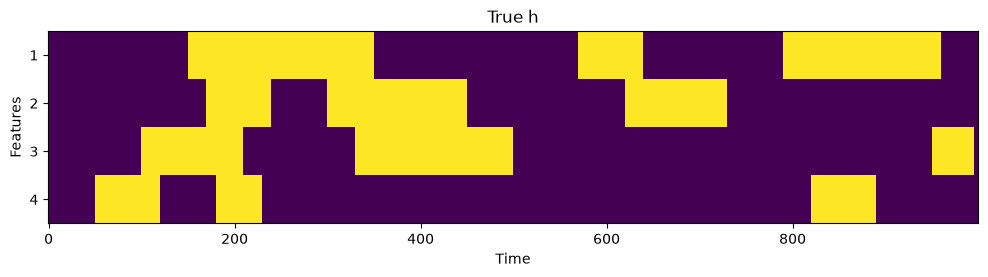

In [20]:
fig = plt.figure(figsize=(12, 2.5))
plt.imshow(h_true_reordered.T, aspect="auto", interpolation="none")
plt.title("True h")
plt.xlabel("Time")
plt.ylabel("Features")
plt.yticks(range(4), np.arange(1, 5))
# plt.savefig("figures/true_h.png")
plt.show()

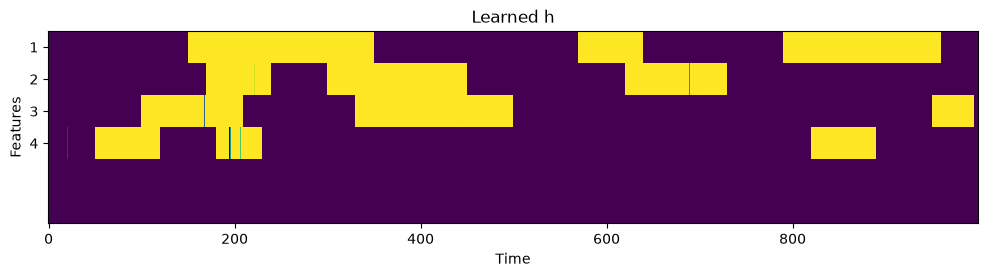

In [21]:
fig = plt.figure(figsize=(12, 2.5))
plt.imshow(h_learned_reordered.T, aspect="auto", interpolation="none")
plt.title("Learned h")
plt.xlabel("Time")
plt.ylabel("Features")
plt.yticks(range(4), np.arange(1, 5))
# plt.savefig("figures/learned_h.png")
plt.show()

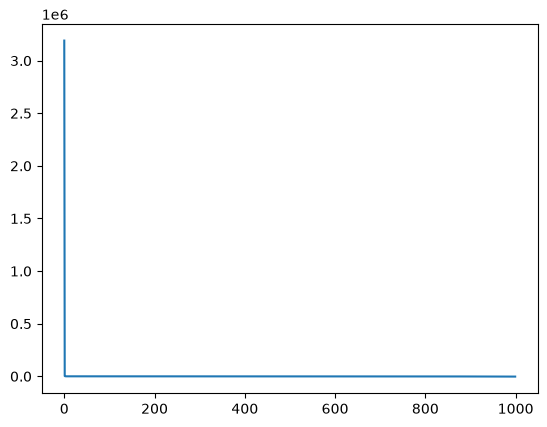

In [ ]:
plt.plot(output["ELBO"])
plt.show()

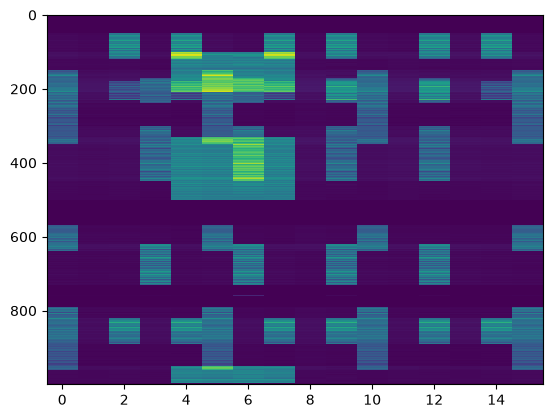

In [29]:
plt.imshow(output["mu_approx"] + output["mu0_approx"], aspect="auto", interpolation="none")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'newplots/true_h.png'

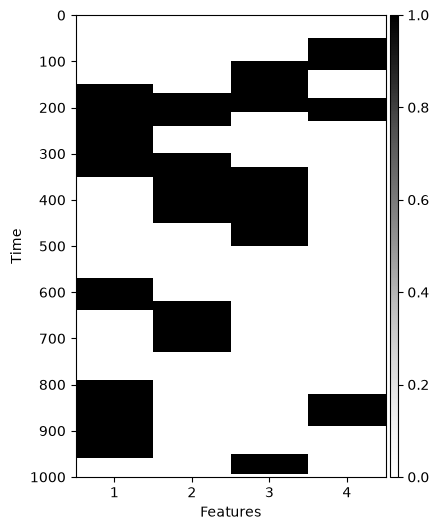

In [30]:
fig = plt.figure(figsize=(4,6))
ax = plt.axes()
im = ax.imshow(h_true_reordered, aspect='auto', interpolation="none", cmap='Greys')
#ax.set_title("True h")
ax.set_ylabel("Time")
ax.set_xlabel("Features")
ax.set_xticks(range(4), np.arange(1, 5))
ax.set_yticks(np.arange(0, 1001, 100))
# plt.savefig("figures/true_h.png")
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/true_h.png",bbox_inches='tight')
plt.savefig("newplots/true_h.png",bbox_inches='tight')
plt.show()

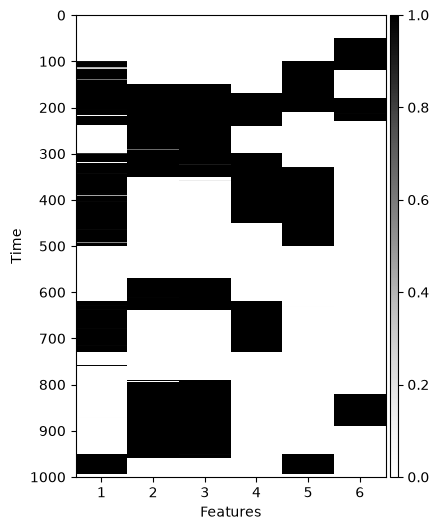

In [31]:
fig = plt.figure(figsize=(4,6))
ax = plt.axes()
im=ax.imshow(h_learned_reordered, aspect='auto', interpolation="none", cmap='Greys')
#ax.set_title("Learned h")
ax.set_ylabel("Time")
ax.set_xlabel("Features")
ax.set_xticks(range(K), np.arange(1, K+1))
ax.set_yticks(np.arange(0, 1001, 100))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/learned_h.png",bbox_inches='tight')
# plt.savefig("newplots/learned_h.png",bbox_inches='tight')
plt.show()

In [32]:
theta_learned = torch.abs(model.theta).detach().cpu().numpy()
theta_learned_reordered = theta_learned[sorted_indices]
theta_true_reordered = theta_true[sorted_indices_true]

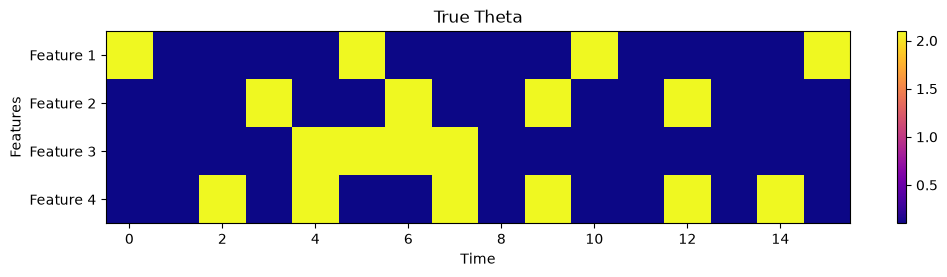

In [33]:
fig = plt.figure(figsize=(12, 2.5))
plt.imshow(theta_true_reordered, aspect="auto", cmap="plasma")
plt.title("True Theta")
plt.xlabel("Time")
plt.ylabel("Features")
plt.yticks(range(4), ["Feature 1", "Feature 2", "Feature 3", "Feature 4"])
plt.colorbar()
# plt.savefig("figures/true_theta.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'newplots/true_theta.png'

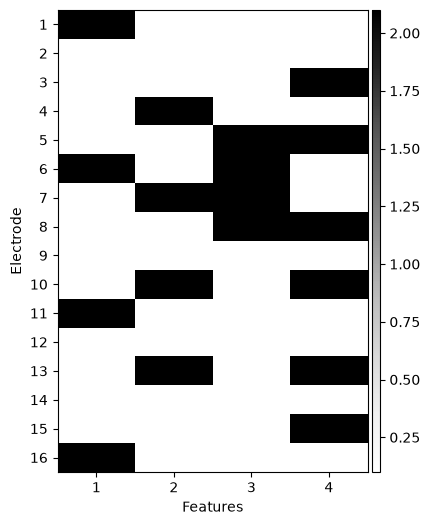

In [34]:
fig = plt.figure(figsize=(4,6))
ax = plt.axes()
im = ax.imshow(theta_true_reordered.T, aspect='auto', cmap="Greys")
#ax.set_title("True Theta")
ax.set_ylabel("Electrode")
ax.set_xlabel("Features")
ax.set_xticks(range(4), np.arange(1, 5))
ax.set_yticks(range(16), np.arange(1, 17))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/true_theta.png",bbox_inches='tight')
plt.savefig("newplots/true_theta.png",bbox_inches='tight')
plt.show()

In [35]:
theta_theta0 = np.vstack([torch.abs(model.theta0).detach().cpu().numpy(), theta_learned_reordered])

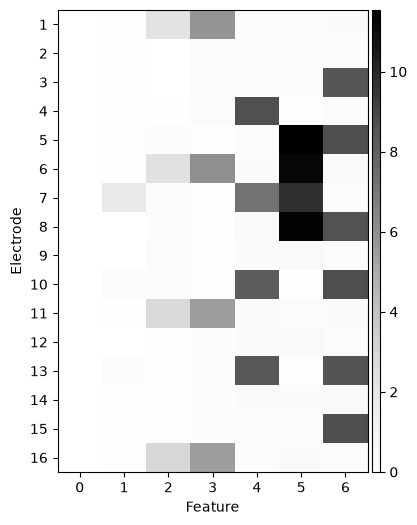

In [36]:
fig = plt.figure(figsize=(4,6))
ax = plt.axes()
im = ax.imshow(theta_theta0.T, cmap="Greys", vmin=0, aspect='auto')
#ax.set_title("Learned Theta")
ax.set_ylabel("Electrode")
ax.set_xlabel("Feature")
ax.set_xticks(range(K+1))
ax.set_yticks(range(16), np.arange(1, 17))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/learned_theta.png",bbox_inches='tight')
# plt.savefig("newplots/learned_theta.png",bbox_inches='tight')
plt.show()

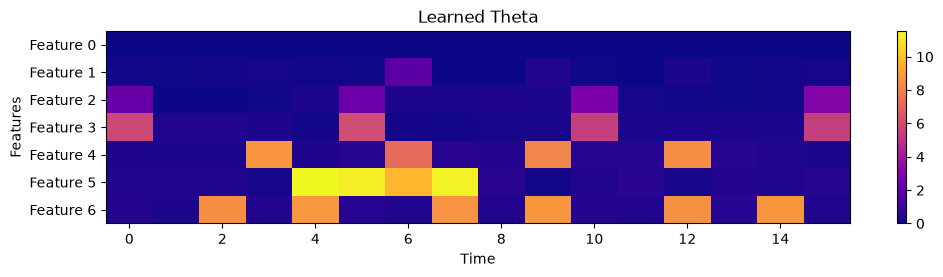

In [37]:
fig = plt.figure(figsize=(12, 2.5))
plt.imshow(theta_theta0, aspect="auto", cmap="plasma", vmin=0)
plt.title("Learned Theta")
plt.xlabel("Time")
plt.ylabel("Features")
plt.yticks(range(K+1), ["Feature 0"] + [f"Feature {i}" for i in range(1, K+1)])
plt.colorbar()
# plt.savefig("figures/learned_theta.png")
plt.show()

In [24]:
theta_scale = theta_learned_reordered.max(axis=1)
theta_scale /= 2

In [25]:
theta_scaled = theta_learned_reordered / theta_scale[:, None]
thetas_scaled = np.vstack([torch.abs(model.theta0).detach().cpu().numpy(), theta_scaled])

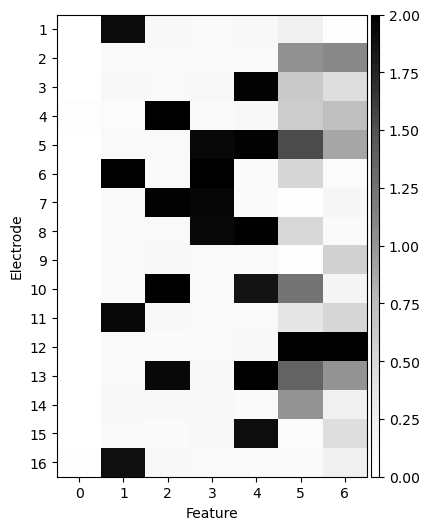

In [28]:
fig = plt.figure(figsize=(4,6))
ax = plt.axes()
im = ax.imshow(thetas_scaled.T, aspect='auto', cmap="Greys", vmin=0)
#ax.set_title("Learned Theta")
ax.set_ylabel("Electrode")
ax.set_xlabel("Feature")
ax.set_xticks(range(K+1))
ax.set_yticks(range(16), np.arange(1, 17))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/learned_theta_rescaled.png",bbox_inches='tight')
# plt.savefig("newplots/learned_theta_rescaled.png",bbox_inches='tight')
plt.show()

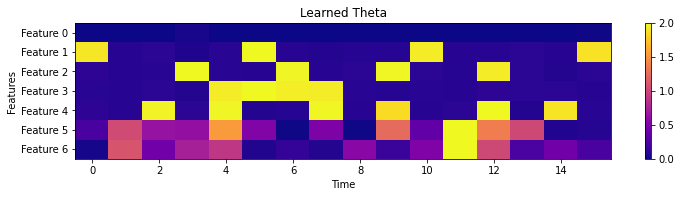

In [41]:
fig = plt.figure(figsize=(12, 2.5))
plt.imshow(thetas_scaled, aspect="auto", cmap="plasma", vmin=0)
plt.title("Learned Theta")
plt.xlabel("Time")
plt.ylabel("Features")
plt.yticks(range(K+1), ["Feature 0"] + [f"Feature {i}" for i in range(1, K+1)])
plt.colorbar()
# plt.savefig("figures/learned_theta.png")
plt.show()

In [42]:
z_learned_scaled = np.exp(z_learned_reordered) * theta_scale

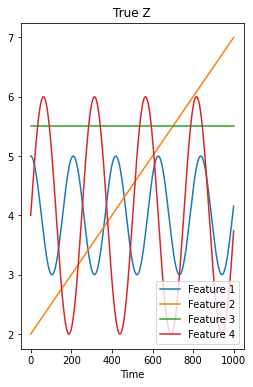

In [94]:
fig = plt.figure(figsize=(4, 6))

# Plot each feature individually
for i in range(z_true_reordered.shape[1]):
    plt.plot(z_true_reordered[:, i], label=f"Feature {i+1}")

plt.title("True Z")
plt.xlabel("Time")

# Add the legend at the lower right corner
plt.legend(loc="lower right")

# Save with tight bounding box
plt.savefig("newplots/true_z.png", bbox_inches='tight')
plt.show()


In [45]:
z_learned_plot = z_learned_scaled.copy()
z_learned_plot[~h_hard_reordered] = np.nan

In [68]:
z_learned_reordered.max()

3.2757642

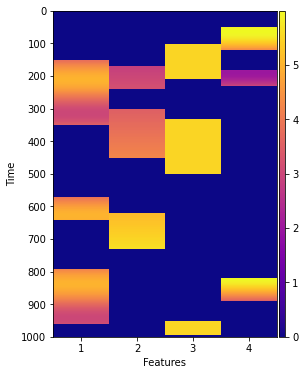

In [77]:
fig = plt.figure(figsize=(4, 6))
ax = plt.axes()
im = ax.imshow((z_true_reordered*h_true_reordered), aspect="auto", cmap="plasma", interpolation="none", vmin=0)
ax.set_ylabel("Time")
ax.set_xlabel("Features")
ax.set_yticks(np.arange(0, 1001, 100))
ax.set_xticks(range(4), np.arange(1, 1+4))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/true_z.png")
# plt.savefig("newplots/true_z.png", bbox_inches='tight')
plt.show()


In [78]:
z_h_learned = z_learned_scaled * h_hard_reordered
z_z0_learned = np.hstack([np.exp(z0_learned), z_h_learned])

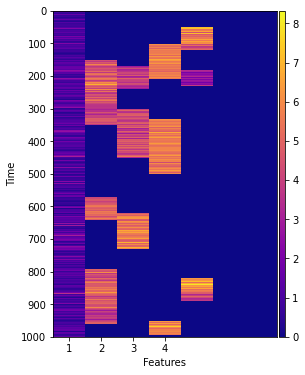

In [81]:
fig = plt.figure(figsize=(4, 6))
ax = plt.axes()
im = ax.imshow(z_z0_learned, aspect="auto", cmap="plasma", interpolation="none", vmin=0)
ax.set_ylabel("Time")
ax.set_xlabel("Features")
ax.set_yticks(np.arange(0, 1001, 100))
ax.set_xticks(range(4), np.arange(1, 1+4))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/learned_z.png")
plt.savefig("newplots/learned_z.png", bbox_inches='tight')
plt.show()


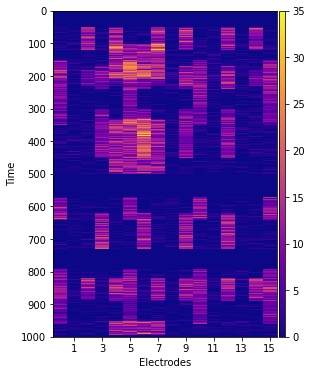

In [93]:
fig = plt.figure(figsize=(4, 6))
ax = plt.axes()
im = ax.imshow(data, aspect="auto", cmap="plasma", interpolation="none")
ax.set_ylabel("Time")
ax.set_xlabel("Electrodes")
ax.set_yticks(np.arange(0, 1001, 100))
ax.set_xticks(np.arange(1, 1+16, 2))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("newplots/data.png", bbox_inches='tight')
plt.show()

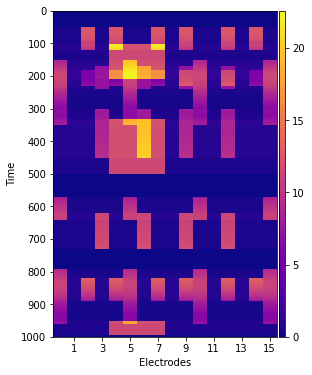

In [90]:
fig = plt.figure(figsize=(4, 6))
ax = plt.axes()
im = ax.imshow(mu_true.sum(axis=0), aspect="auto", cmap="plasma", interpolation="none")
ax.set_ylabel("Time")
ax.set_xlabel("Electrodes")
ax.set_yticks(np.arange(0, 1001, 100))
ax.set_xticks(np.arange(1, 1+16, 2))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/true_mu.png")
# plt.savefig("newplots/true_mu.png", bbox_inches='tight')
plt.show()

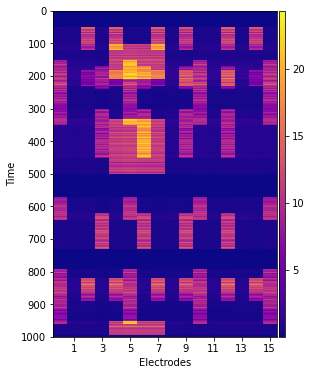

In [91]:
fig = plt.figure(figsize=(4, 6))
ax = plt.axes()
im = ax.imshow(mu_approx+mu0_approx, aspect="auto", cmap="plasma", interpolation="none")
ax.set_ylabel("Time")
ax.set_xlabel("Electrodes")
ax.set_yticks(np.arange(0, 1001, 100))
ax.set_xticks(np.arange(1, 1+16, 2))
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
# plt.savefig("figures/learned_mu.png")
# plt.savefig("newplots/learned_mu.png", bbox_inches='tight')
plt.show()

In [59]:
S = 2000
M = 89

In [58]:
import torch.distributions as td

In [60]:
log_weights = []
model.eval()

for s in range(S):
    # Forward pass will sample (h, z, z0) via rsample()
    h_logit, log_prob_h, z, log_prob_z, z0, log_prob_z0, rho_logit = model(torch.from_numpy(data[:T]).float())

    # Compute log joint (same as in your loss)
    h_t = torch.sigmoid(h_logit)
    mu_t = torch.sigmoid(h_t) * torch.exp(z) @ torch.abs(model.theta)     # shape (D,)
    mu0_t = torch.exp(z0) @ torch.abs(model.theta0)          # shape (D,)
    mu_total = mu_t + mu0_t    
    
    p_log_prob = td.Poisson(mu_total).log_prob(torch.from_numpy(data[:T]).float()).sum(dim=1)  # (T,)
    
    ## z_loss
    z_loss_dist = td.multivariate_normal.MultivariateNormal(
        z[:-1] @ torch.diag(model.A), torch.diag(torch.abs(model.sigp[:, 0]))
    )
    z_loss = z_loss_dist.log_prob(z[1:]).mean()

    temp_loss = 0.
    for k in range(model.K):
        # shape (T-1,1) for logits => compare with h_logit[1:, k]
        # We'll skip the last time since there's no h[t+1] to predict
        dist_h = td.relaxed_bernoulli.LogitRelaxedBernoulli(
            model.temp, logits=rho_logit[k][:-1]
        )
        temp_loss_k = dist_h.log_prob(h_logit[1:, k].view(-1,1)).mean()
        temp_loss += temp_loss_k
    # 6) AR for z0
    z0_loss_dist = td.normal.Normal(model.A0 * z0[:-1], torch.abs(model.sigp0))
    z0_loss = z0_loss_dist.log_prob(z0[1:]).mean()
    
    log_p = p_log_prob.mean() + z_loss + z0_loss + temp_loss

    log_q = log_prob_h.sum(dim=1).mean() + log_prob_z.mean() + log_prob_z0.mean()
    log_weights.append((log_p - log_q).item())


In [382]:
# PSIS diagnostic
import numpy as np
from scipy.stats import genpareto

lw = np.array(log_weights)
lw -= np.max(lw)
w = np.exp(lw)

tail_w = np.sort(w)[-int(S*0.2):]
tail_w_shifted = tail_w - np.min(tail_w)
k_hat, loc, scale = genpareto.fit(tail_w_shifted)
print("Estimated k̂ =", k_hat)


Estimated k̂ = -0.11360505256538245


In [374]:
k_hat, loc, scale = genpareto.fit(np.exp(log_weights))

In [375]:
k_hat

0.48186641197715774

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Example data
# fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))
# data_matrix = z_true_reordered.copy() # Your main data matrix (1000x4)
# binary_matrix = h_true_reordered.copy()  # Your binary matrix (1000x4)

# # Plot each column as a separate line plot
# for col in range(data_matrix.shape[1]):
#     for i in range(1, data_matrix.shape[0]):
#         x_values = [i - 1, i]  # x-axis values for the line segment
#         y_values = [data_matrix[i - 1, col], data_matrix[i, col]]  # y-axis values for the line segment
#         alpha_value = 0.05 if binary_matrix[i, col] == 0 else 1.0  # Set alpha based on binary matrix
        
#         ax[0].plot(x_values, y_values, color=f"C{col}", alpha=alpha_value)

# ax[1].plot(z_learned_plot)
# ax[0].set_title("True z")
# ax[1].set_title("Learned z (scaled)")
# plt.show()
